In [1]:
print("hello")


hello


In [ ]:
#add hf token here 

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `Macbook-air-m4` has been saved to /Users/ramchandrabharatmulik/.cache/huggingface/stored_tokens
Your token has been saved to /Users/ramchandrabharatmulik/.cache/huggingface/token
Login successful.
The current active token is: `Macbook-air-m4`


In [4]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [25]:
!pip install torch torchvision torchaudio --quiet

In [26]:
!pip install transformers datasets accelerate --quiet

In [27]:
!pip install librosa pydub soundfile gTTS --quiet

In [28]:
!pip install torch==2.3.0 --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.3.0-cp312-none-macosx_11_0_arm64.whl (61.0 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.9.0
    Uninstalling torch-2.9.0:
      Successfully uninstalled torch-2.9.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.9.0 requires torch==2.9.0, but you have torch 2.3.0 which is incompatible.
torchvision 0.24.0 requires torch==2.9.0, but you have torch 2.3.0 which is incompatible.


In [31]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [1]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech, SpeechT5HifiGan
from datasets import load_dataset
import soundfile as sf
import librosa
from pydub import AudioSegment
import numpy as np
import os

/Users/ramchandrabharatmulik/Developer/Major-project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 2. Apple Silicon (MPS) Setup ---
def get_apple_silicon_device():
    """Initializes and returns the PyTorch MPS device."""
    if not torch.backends.mps.is_available():
        if not torch.backends.mps.is_built():
            print("🔴 MPS not available because the current PyTorch install was not "
                  "built with MPS enabled.")
            print("Running on CPU instead.")
            return torch.device("cpu")
        else:
            print("🔴 MPS not available. Running on CPU instead.")
            return torch.device("cpu")
    
    device = torch.device("mps")
    print(f"✅ Apple Silicon MPS device acquired: {device}")
    return device

In [3]:
# --- 3. Audio Helper Functions ---
def load_audio_from_mp3(mp3_file_path, target_sr=16000):
    """
    Loads an MP3 file, decodes it, resamples to target_sr, 
    and returns it as a NumPy array.
    """
    try:
        speech_array, sampling_rate = librosa.load(mp3_file_path, sr=target_sr, mono=True)
        print(f"Audio loaded from {mp3_file_path} and resampled to {target_sr} Hz.")
        return speech_array
    except Exception as e:
        print(f"🔴 Error loading MP3 file {mp3_file_path}: {e}")
        return None

In [4]:
def save_audio_to_mp3(speech_array, sampling_rate, output_mp3_file_path):
    """
    Saves a NumPy array of speech data as an MP3 file.
    Requires ffmpeg to be installed (which you did with Homebrew).
    """
    try:
        # 1. Normalize and convert to 16-bit PCM
        if np.max(np.abs(speech_array)) > 1.0:
            speech_array = speech_array / np.max(np.abs(speech_array))
        
        speech_array_int16 = (speech_array * 32767).astype(np.int16)

        # 2. Create an AudioSegment
        audio_segment = AudioSegment(
            speech_array_int16.tobytes(),
            frame_rate=sampling_rate,
            sample_width=speech_array_int16.dtype.itemsize,
            channels=1  # Mono
        )

        # 3. Export as MP3
        audio_segment.export(output_mp3_file_path, format="mp3")
        print(f"✅ Speech saved to {output_mp3_file_path}")
    except Exception as e:
        print(f"🔴 Error saving MP3 file: {e}")
        print("Ensure ffmpeg is installed (run 'brew install ffmpeg').")

In [5]:
import os

# To unset the environment variable
if 'HF_TOKEN' in os.environ:
    del os.environ['HF_TOKEN']

# To verify it has been unset (this will print None)
print(os.environ.get('HF_TOKEN'))

None


In [6]:
# --- Model Loading Functions ---
import torch
import torch.hub
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM

def load_stt_model(device):
    """Loads the Speech-to-Text (STT) model."""
    print("Loading STT model: openai/whisper-base...")
    stt_pipeline = pipeline(
        "automatic-speech-recognition",
        model="openai/whisper-base",
        device=device
    )
    print("✅ STT model loaded.")
    return stt_pipeline


def load_chatbot_model(device):
    """Loads the Chatbot model."""
    print("Loading Chatbot model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...")
    chat_model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    
    chat_tokenizer = AutoTokenizer.from_pretrained(chat_model_id)
    chat_model = AutoModelForCausalLM.from_pretrained(
        chat_model_id,
        torch_dtype=torch.float16,  # Use float16 for M4 performance
        device_map=device
    )
    print("✅ Chatbot model loaded.")
    return chat_tokenizer, chat_model






# --- THIS IS THE UPDATED SPEECH GENERATOR ---
def generate_speech(tts_pipeline, speaker_embeddings, text_response):
    """Converts text response to a speech array using the pipeline."""
    print("[3/3] Synthesizing speech...")
    
    with torch.no_grad():
        # The pipeline handles all the steps internally
        speech = tts_pipeline(
        text_response, 
        forward_params={"speaker_embeddings": speaker_embeddings}
    )
    
    # The pipeline output is a dictionary
    speech_array = speech["audio"]
    sampling_rate = speech["sampling_rate"]
    
    return speech_array, sampling_rate

In [7]:
# --- Helper Functions ---
def transcribe_audio(stt_pipeline, speech_array):
    """Converts speech array to text."""
    print("\n[1/3] Transcribing audio...")
    if speech_array is None:
        return None
    
    result = stt_pipeline(speech_array.copy(), return_timestamps=True)
    text = result["text"]
    print(f"Transcript: '{text}'")
    return text


def get_chat_response(chat_tokenizer, chat_model, device, conversation_history, text_prompt):
    """Gets a response from the chatbot model."""
    print("[2/3] Generating chat response...")
    
    conversation_history.append({"role": "user", "content": text_prompt})
    
    chat_prompt = chat_tokenizer.apply_chat_template(
        conversation_history, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    inputs = chat_tokenizer(
        chat_prompt, return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        outputs = chat_model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=True,
            temperature=0.7,
            top_k=50,
            top_p=0.95
        )
        
    full_response = chat_tokenizer.decode(outputs[0], skip_special_tokens=False)
    
    if "<|assistant|>\n" in full_response:
        response_only = full_response.split("<|assistant|>\n")[-1]
    elif "<start_of_turn>model\n" in full_response:
        response_only = full_response.split("<start_of_turn>model\n")[-1]
    else:
        response_only = full_response.split("model\n")[-1]

    response_only = response_only.replace("</s>", "").strip()
    conversation_history.append({"role": "model", "content": response_only})
    
    print(f"Chatbot: '{response_only}'")
    return response_only


In [8]:
INPUT_FILE = "DP Road (1).mp3"
OUTPUT_FILE = "output.mp3"

In [9]:
import torch
from transformers import pipeline

def load_tts_model(device):
    """Loads the Text-to-Speech (TTS) pipeline AND a synthetic speaker embedding."""
    
    print("Loading TTS pipeline: microsoft/speecht5_tts...")
    try:
        tts_pipeline = pipeline(
            "text-to-speech", 
            model="microsoft/speecht5_tts",
            device=device
        )
        print("✅ TTS pipeline loaded.")
    except Exception as e:
        print(f"🔴 Failed to load TTS pipeline: {e}")
        return None, None  # Return two Nones to avoid unpack error

    # --- Create a synthetic speaker embedding ---
    # This is required by the model, as proven by the ValueError.
    print("Creating synthetic speaker embedding (generic voice)...")
    try:
        # SpeechT5 expects a tensor of shape (1, 512)
        speaker_embeddings = torch.randn((1, 512)).to(device)
        print("✅ Synthetic speaker embedding created.")
    except Exception as e:
        print(f"🔴 Failed to create speaker embedding: {e}")
        return None, None # Return two Nones

    # Return BOTH the pipeline and the embeddings
    return tts_pipeline, speaker_embeddings

In [10]:
mps_device = get_apple_silicon_device()

✅ Apple Silicon MPS device acquired: mps


In [11]:
# --- 1. Define Chatbot Persona ---
conversation_history = [
    {"role": "system", "content": "You are a kind, empathetic, and supportive mental health assistant. Your goal is to listen to the user, validate their feelings, and provide helpful, positive, and non-judgmental guidance. Do not give medical advice. Keep your responses thoughtful but concise."}
]
print("--- 1. Chatbot persona set ---")

# --- 2. Load All Models ---
print("\n--- 2. Loading All Models ---")
stt_pipeline = load_stt_model(mps_device)
chat_tokenizer, chat_model = load_chatbot_model(mps_device)

--- 1. Chatbot persona set ---

--- 2. Loading All Models ---
Loading STT model: openai/whisper-base...


Device set to use mps


✅ STT model loaded.
Loading Chatbot model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Chatbot model loaded.


In [12]:
tts_pipeline, speaker_embeddings = load_tts_model(mps_device)

Loading TTS pipeline: microsoft/speecht5_tts...


Device set to use mps


✅ TTS pipeline loaded.
Creating synthetic speaker embedding (generic voice)...
✅ Synthetic speaker embedding created.


In [21]:
# --- 3. Load input audio ---
print(f"\n--- 3. Starting Chatbot Pipeline with {INPUT_FILE} ---")
input_speech = load_audio_from_mp3(INPUT_FILE, target_sr=16000)


--- 3. Starting Chatbot Pipeline with DP Road (1).mp3 ---
Audio loaded from DP Road (1).mp3 and resampled to 16000 Hz.


In [22]:
user_text = transcribe_audio(stt_pipeline, input_speech)


[1/3] Transcribing audio...
Transcript: ' I'm remodeling. I've used like 90 and I'm done with my top. I'll make a disaster with 30 days. We won't start. You know, please wait and watch. I can only sense this right now. Even signness, which I'm continuously afro that never weeks, even when everything looks fine on the outside.'


In [23]:
user_text

" I'm remodeling. I've used like 90 and I'm done with my top. I'll make a disaster with 30 days. We won't start. You know, please wait and watch. I can only sense this right now. Even signness, which I'm continuously afro that never weeks, even when everything looks fine on the outside."

In [24]:
bot_text = get_chat_response(
            chat_tokenizer, chat_model, mps_device, conversation_history, user_text
        )

[2/3] Generating chat response...
Chatbot: 'Response: Thank you for sharing your remodeling experiences and concerns. I understand the feeling of being overwhelmed and frustrated with the process. Please let me know if there are any areas where you feel you're making progress or if you're struggling with any specific issues. I would be happy to provide guidance and support to help you through this process and ensure that you're making the most of your time and resources. Please don't hesitate to reach out if you have any questions or concerns. I'm here to help.'


In [26]:
import re
import numpy as np

# 1. Split the bot_text into sentences
# This splits the text at any '.', '?', or '!' that is followed by a space
sentences = re.split(r'(?<=[.?!]) +', bot_text)

all_speech_arrays = []
print("Splitting long text into sentences and generating audio chunks...")

# 2. Generate audio for each sentence one by one
for i, sentence in enumerate(sentences):
    sentence = sentence.strip()
    if sentence:  # Make sure it's not an empty string
        print(f"\n--- Generating Chunk {i+1}/{len(sentences)} ---")
        print(f"Text: '{sentence}'")
        
        # Call your existing generate_speech function from Cell 6
        speech_array, sr = generate_speech(
            tts_pipeline, speaker_embeddings, sentence
        )
        all_speech_arrays.append(speech_array)

# 3. Combine all the small audio arrays into one big one
print("\n✅ All chunks generated. Combining into one audio file...")
output_speech = np.concatenate(all_speech_arrays)

# 'sr' will be the sampling rate from the last chunk, which is fine
print("✅ Combined speech array created.")

Splitting long text into sentences and generating audio chunks...

--- Generating Chunk 1/6 ---
Text: 'Response: Thank you for sharing your remodeling experiences and concerns.'
[3/3] Synthesizing speech...

--- Generating Chunk 2/6 ---
Text: 'I understand the feeling of being overwhelmed and frustrated with the process.'
[3/3] Synthesizing speech...

--- Generating Chunk 3/6 ---
Text: 'Please let me know if there are any areas where you feel you're making progress or if you're struggling with any specific issues.'
[3/3] Synthesizing speech...

--- Generating Chunk 4/6 ---
Text: 'I would be happy to provide guidance and support to help you through this process and ensure that you're making the most of your time and resources.'
[3/3] Synthesizing speech...

--- Generating Chunk 5/6 ---
Text: 'Please don't hesitate to reach out if you have any questions or concerns.'
[3/3] Synthesizing speech...

--- Generating Chunk 6/6 ---
Text: 'I'm here to help.'
[3/3] Synthesizing speech...

✅ All c

In [27]:
save_audio_to_mp3(output_speech, sr, OUTPUT_FILE)

print(f"\n--- Pipeline Complete ---")
print(f"Listen to the response in {OUTPUT_FILE}")

✅ Speech saved to output.mp3

--- Pipeline Complete ---
Listen to the response in output.mp3


In [49]:
!brew install graphviz

Python(2455) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
corepack: Package acting as bridge between Node projects and their package managers
doh: Stand-alone DNS-over-HTTPS resolver using libcurl
hexhog: Hex viewer/editor
intelli-shell: Like IntelliSense, but for shells
ktea: Kafka TUI client
mcat: Terminal image, video, directory, and Markdown viewer
mysql-to-sqlite3: Transfer data from MySQL to SQLite
openlist: New AList fork addressing anti-trust issues
openssl@1.1: Cryptography and SSL/TLS Toolkit
sqlite3-to-mysql: Transfer data from SQLite to MySQL
tscriptify: Golang struct to TypeScript class/interface converter
tuios: Terminal UI OS (Terminal Multiplexer)
==> New Casks
freepdf: Reader that supports translating PDF documents
nkoda: Digital s

Python(5338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


✅ Pipeline diagram saved as model_pipeline.png


Python(5339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


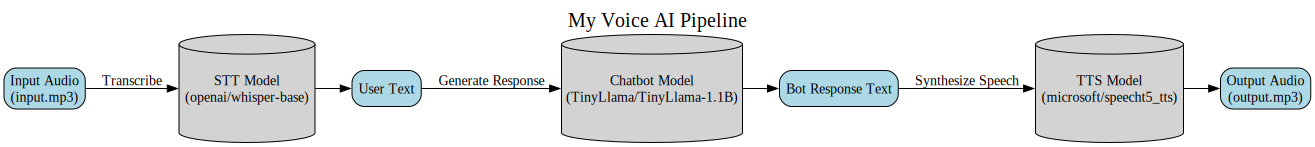

In [50]:
from graphviz import Digraph

# Create a new directed graph
dot = Digraph(comment='Model Pipeline')
dot.attr(rankdir='LR', labelloc='t', label='My Voice AI Pipeline', fontsize='20')

# Define the nodes (stages)
dot.attr('node', shape='box', style='filled,rounded', fillcolor='lightblue')
dot.node('A', 'Input Audio\n(input.mp3)')
dot.node('C', 'User Text')
dot.node('E', 'Bot Response Text')
dot.node('G', 'Output Audio\n(output.mp3)')

# Define the model nodes
dot.attr('node', shape='cylinder', style='filled', fillcolor='lightgrey', height='1.5')
dot.node('B', 'STT Model\n(openai/whisper-base)')
dot.node('D', 'Chatbot Model\n(TinyLlama/TinyLlama-1.1B)')
dot.node('F', 'TTS Model\n(microsoft/speecht5_tts)')

# Define the edges (flow of data)
dot.edge('A', 'B', 'Transcribe')
dot.edge('B', 'C')
dot.edge('C', 'D', 'Generate Response')
dot.edge('D', 'E')
dot.edge('E', 'F', 'Synthesize Speech')
dot.edge('F', 'G')

# Save and render the graph
# This will create a 'model_pipeline.png' file in your directory
output_filename = 'model_pipeline'
dot.render(output_filename, format='png', cleanup=True)

print(f"✅ Pipeline diagram saved as {output_filename}.png")

# You can also display it directly in the notebook (if supported)
dot